##  **A. Enfoque de validación** 

In [1]:
import pandas as pd
#no se si hicieron otra "respondieron" definitiva, agarré (generé) la primera que hicieron el tp1 que tiene la variable pobre.
#tiene 70% pobres...
#no use la respondieron original porque no tiene la variable pobre
respondieron=pd.read_excel("C:/Users/loloa/OneDrive/Escritorio/facu/Ciencia de datos/tp/Ciencia-de-Datos/TP1/respondieron_este.xlsx")
print(respondieron.head())
#hice pip install sklearn en la terminal para que ande sklearn
print(respondieron.columns)


   ano4  ch04  ch06  ch07  ch08  nivel_ed  estado  cat_inac         ipcf  \
0  2005     1     4     5   1.0         7     4.0         5   280.000000   
1  2005     2     1     5  12.0         7     4.0         5   400.000000   
2  2005     2    78     4   1.0         6     3.0         1  3200.000000   
3  2005     1    16     5   1.0         3     3.0         3   435.000000   
4  2005     1    -1     5   1.0         7     4.0         5   517.333333   

   ch10  ...  pp02e  pp02i  ch09    codusu   sexo  nivel ed adulto_equiv  \
0   1.0  ...    NaN    NaN     2  125082    Varón       NaN         0.55   
1   NaN  ...    NaN    NaN     3  125409    Mujer       NaN         0.37   
2   2.0  ...    NaN    2.0     1  126610    Mujer       NaN         0.63   
3   1.0  ...    NaN    2.0     1  126653    Varón       NaN         1.03   
4   NaN  ...    NaN    NaN     3  126852    Varón       NaN         0.35   

  ad_equiv_hogar  ingreso_necesario  pobre  
0           0.55           112.7885      

In [2]:
norespondieron=pd.read_excel("C:/Users/loloa/OneDrive/Escritorio/facu/Ciencia de datos/tp/Ciencia-de-Datos/TP1/norespondieron.xlsx")
#para el norespondieron agarré el archivo exportado del tp1 directamente

In [3]:
#chequando los valores
print(respondieron["pobre"].unique())
pobre_percentages = respondieron['pobre'].value_counts(normalize=True) * 100

# Print the resulting Series
print(pobre_percentages)


[0 1]
pobre
1    70.566559
0    29.433441
Name: proportion, dtype: float64


In [4]:
import sklearn 
#create a train and test base using train_test_split. make the train 70% and test 30%. use random state instance: 444


from sklearn.model_selection import train_test_split

X = respondieron.drop(columns=['pobre','ipcf']) #itf no esta en la tabla. dropee ipcf como pide el ej.

y = respondieron['pobre']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=444)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (12157, 21)
Shape of X_test: (5211, 21)
Shape of y_train: (12157,)
Shape of y_test: (5211,)


In [5]:
from sklearn.model_selection import train_test_split

YEAR_COL = "ano4"
years = sorted(respondieron[YEAR_COL].dropna().unique())

splits = {}

for year in years:
    # Filtrar cada año
    dfy = respondieron[respondieron[YEAR_COL] == year].copy()

    # Variable dependiente
    y = dfy["pobre"].copy()

    # Variables independientes (sin 'pobre', 'ingreso' ni 'ipcf')
    X = dfy.drop(columns=["pobre", "ingreso", "ipcf"], errors="ignore")

    # División 70/30 con semilla 444
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, random_state=444, stratify=y
    )

    # 💡 AGREGAR AQUÍ la columna de unos (intercepto)
    Xtr = Xtr.assign(intercepto=1)
    Xte = Xte.assign(intercepto=1)

    # Guardar los splits por año
    splits[year] = {"X_train": Xtr, "X_test": Xte, "y_train": ytr, "y_test": yte}

# Verificación
print("Años con split:", years)
for y in years:
    Xt, Xs = splits[y]["X_train"], splits[y]["X_test"]
    print(f"{y} -> X_train: {Xt.shape}, X_test: {Xs.shape}, intercepto incluido: {'intercepto' in Xt.columns}")


Años con split: [np.int64(2005), np.int64(2025)]
2005 -> X_train: (5619, 22), X_test: (2409, 22), intercepto incluido: True
2025 -> X_train: (6538, 22), X_test: (2802, 22), intercepto incluido: True


### Ejercicio 1

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1) Cargo la base y armo splits por año (70/30, semilla 444)

YEAR_COL = "ano4"

splits = {}
years = sorted(respondieron[YEAR_COL].dropna().unique())
for year in years:
    dfy = respondieron[respondieron[YEAR_COL] == year].copy()
    y = dfy["pobre"].copy()
    X = dfy.drop(columns=["pobre", "ingreso", "ipcf"], errors="ignore")

    strat = y if y.nunique() > 1 else None
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, random_state=444, stratify=strat
    )
    Xtr = Xtr.assign(intercepto=1)
    Xte = Xte.assign(intercepto=1)
    splits[year] = {"X_train": Xtr, "X_test": Xte, "y_train": ytr, "y_test": yte}

# 2) Elijo el año a reportar (podés cambiarlo a 2005 si querés)
año = max(splits.keys())
X_train = splits[año]["X_train"].copy()
X_test  = splits[año]["X_test"].copy()
y_train = splits[año]["y_train"].copy()

# 3) Selección objetiva de X: numéricas, excluyendo el intercepto; priorizo las más asociadas a y (|corr|)
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "intercepto"]

corrs = {}
for c in num_cols:
    x = X_train[c].copy()
    if x.isna().all():
        corrs[c] = np.nan
    else:
        corrs[c] = np.corrcoef(x.fillna(x.median()), y_train)[0,1]
corrs_s = pd.Series(corrs).abs().sort_values(ascending=False)

# ajustá la cantidad si querés (ej.: 10–15 variables que limpiaron previamente)
variables_seleccionadas = corrs_s.dropna().head(12).index.tolist()

# 4) Tabla de diferencias de medias
medias_train = X_train[variables_seleccionadas].mean()
medias_test  = X_test[variables_seleccionadas].mean()

tabla = pd.DataFrame({
    "Media_train": medias_train,
    "Media_test": medias_test
})
tabla["Diferencia_media"] = tabla["Media_train"] - tabla["Media_test"]
tabla["Dif_rel_%"] = (tabla["Diferencia_media"] / tabla["Media_train"].replace(0, np.nan)).abs() * 100

# 5) Contraste de medias (Welch)
try:
    from scipy import stats
    pvals = {}
    for c in variables_seleccionadas:
        a = X_train[c].dropna().values
        b = X_test[c].dropna().values
        pvals[c] = stats.ttest_ind(a, b, equal_var=False).pvalue if len(a)>1 and len(b)>1 else np.nan
    tabla["p_value"] = pd.Series(pvals)
    tabla["signif_0.05"] = tabla["p_value"] < 0.05
except Exception:
    tabla["p_value"] = np.nan
    tabla["signif_0.05"] = np.nan

tabla_dif = tabla.sort_values("Dif_rel_%", ascending=False).round(4)
print(f"Diferencia de medias entre entrenamiento y testeo – Año {año}")
display(tabla_dif)

Diferencia de medias entre entrenamiento y testeo – Año 2025


C:\Users\loloa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\loloa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Media_train,Media_test,Diferencia_media,Dif_rel_%,p_value,signif_0.05
cat_inac,1.749300e+00,1.708400e+00,0.0409,2.3374,0.3465,False
ch08,2.107400e+00,2.063900e+00,0.0435,2.0637,0.2740,False
ch15,1.408200e+00,1.386500e+00,0.0217,1.5423,0.2163,False
ch07,3.437700e+00,3.395400e+00,0.0423,1.2309,0.2593,False
ch06,3.718770e+01,3.676620e+01,0.4214,1.1333,0.4060,False
nivel_ed,3.719500e+00,3.678400e+00,0.0410,1.1034,0.3077,False
ch09,1.085700e+00,1.076400e+00,0.0093,0.8547,0.1928,False
ch10,1.726300e+00,1.713400e+00,0.0129,0.7475,0.2455,False
ingreso_necesario,1.018420e+06,1.021849e+06,-3428.7242,0.3367,0.7702,False
ad_equiv_hogar,2.788800e+00,2.798200e+00,-0.0094,0.3367,0.7702,False


### Ejercicio 2

In [7]:
# Asumiendo que la columna se llama 'ano4'
respondieron_2005 = respondieron[respondieron["ano4"] == 2005].copy()
respondieron_2025 = respondieron[respondieron["ano4"] == 2025].copy()

norespondieron_2005 = norespondieron[norespondieron["ano4"] == 2005].copy()
norespondieron_2025 = norespondieron[norespondieron["ano4"] == 2025].copy()

# Mostrar la cantidad de filas para verificar
print("Respondieron 2005:", respondieron_2005.shape)
print("Respondieron 2025:", respondieron_2025.shape)
print("No respondieron 2005:", norespondieron_2005.shape)
print("No respondieron 2025:", norespondieron_2025.shape)

Respondieron 2005: (8028, 23)
Respondieron 2025: (9340, 23)
No respondieron 2005: (107, 19)
No respondieron 2025: (4461, 19)


## **B. Modelo de Regresion Logistica**

### Ejercicio 3: Estimación y Efectos Marginales

In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Año de trabajo
año = 2025
X_train = splits[año]["X_train"].copy()
y_train = splits[año]["y_train"].copy()

# Variables del modelo (ajustá a tus limpias del TP)
variables_modelo = [
    'ch06','ch07','ch08','ch09','ch10',
    'nivel_ed','cat_inac','ad_equiv_hogar'
]
variables_modelo = [v for v in variables_modelo if v in X_train.columns]

# Matriz X + intercepto (ya existe, por las dudas lo tomo explícito)
X = X_train[variables_modelo + ['intercepto']].copy()

# 1) Limpiar infinitos y NAs (requisito de statsmodels)
X = X.replace([np.inf, -np.inf], np.nan)
dfm = pd.concat([y_train.rename('pobre'), X], axis=1)

# Opción 1: eliminar filas con NA en cualquiera de las columnas del modelo
dfm = dfm.dropna(axis=0)

y = dfm['pobre'].astype(int)
X = dfm.drop(columns='pobre')

# 2) Estimar Logit
logit = sm.Logit(y, X)
res = logit.fit()

# 3) Tabla de coeficientes, errores estándar y odds ratios
tabla_logit = pd.DataFrame({
    'Coeficiente': res.params,
    'Error_Estandar': res.bse,
    'Odds_Ratio': np.exp(res.params)
}).round(4)

print("Resultados Logit — Año", año)
display(tabla_logit)

# 4) Efectos marginales promedio (AME)
mfx = res.get_margeff(at='overall')          # AME
tabla_mfx = mfx.summary_frame()               # columnas: dy/dx, Std. Err., z, P>|z|, [0.025, 0.975]
tabla_mfx = tabla_mfx.rename(columns={'dy/dx':'AME'}).round(4)

print("Efectos marginales promedio (AME) — Año", año)
display(tabla_mfx)

# (Opcional) exportar a CSV
# tabla_logit.to_csv("logit_coeficientes_{}.csv".format(año), index=True)
# tabla_mfx.to_csv("logit_marginales_{}.csv".format(año), index=True)



Optimization terminated successfully.
         Current function value: 0.277419
         Iterations 8
Resultados Logit — Año 2025


,Coeficiente,Error_Estandar,Odds_Ratio
ch06,-0.0014,0.0027,0.9986
ch07,0.0334,0.0307,1.0340
ch08,0.0847,0.0224,1.0884
ch09,0.7281,0.2831,2.0712
ch10,0.1841,0.1373,1.2021
nivel_ed,-0.3599,0.0289,0.6977
cat_inac,0.2110,0.0280,1.2349
ad_equiv_hogar,2.4020,0.0796,11.0450
intercepto,-3.9793,0.4231,0.0187


Efectos marginales promedio (AME) — Año 2025


,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
ch06,-0.0001,0.0002,-0.5180,0.6045,-0.0006,0.0003
ch07,0.0029,0.0027,1.0873,0.2769,-0.0024,0.0082
ch08,0.0075,0.0020,3.7962,0.0001,0.0036,0.0113
ch09,0.0641,0.0248,2.5779,0.0099,0.0154,0.1128
ch10,0.0162,0.0121,1.3418,0.1797,-0.0075,0.0398
nivel_ed,-0.0317,0.0024,-13.2439,0.0000,-0.0363,-0.0270
cat_inac,0.0186,0.0024,7.7021,0.0000,0.0138,0.0233
ad_equiv_hogar,0.2113,0.0042,49.9806,0.0000,0.2030,0.2196


### Ejercicio 4: Visualización

C:\Users\loloa\AppData\Local\Temp\ipykernel_6120\3497891162.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


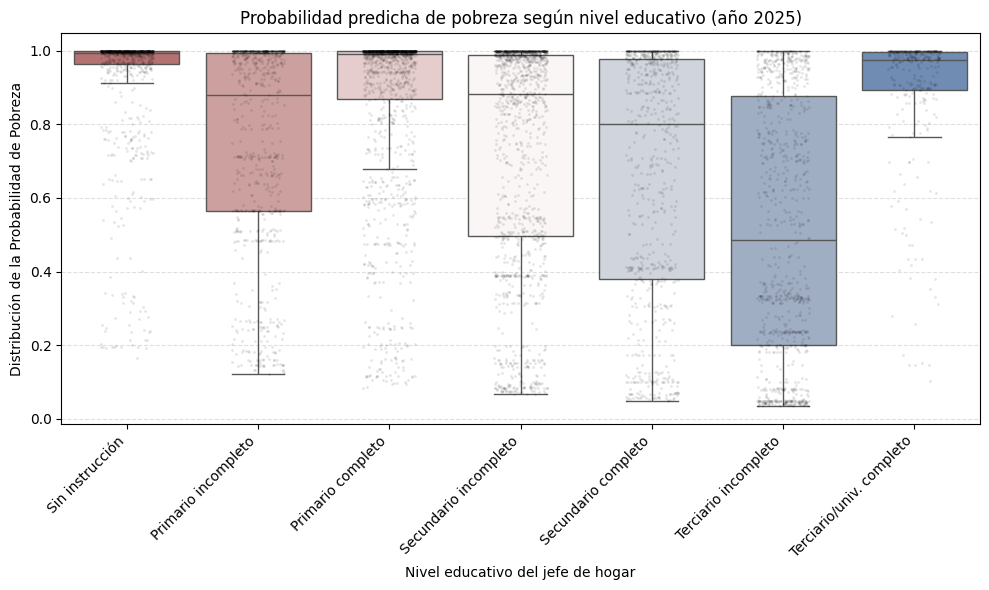

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  # <-- Importar Seaborn

# --- Tu código de preparación de datos (sin cambios) ---

# Año y variable a graficar
año = 2025
variable = 'nivel_ed'

# Probabilidad predicha (Asumiendo que 'splits' y 'res' ya existen)
X_train = splits[año]["X_train"]
prob_pred = res.predict(X_train[res.params.index])

# DataFrame para graficar
df_plot = pd.DataFrame({
    variable: X_train[variable], 
    'Prob_Pobre': prob_pred
})

# Etiquetas del nivel educativo
etiquetas_nivel = {
    1: "Sin instrucción",
    2: "Primario incompleto",
    3: "Primario completo",
    4: "Secundario incompleto",
    5: "Secundario completo",
    6: "Terciario incompleto",
    7: "Terciario/univ. completo"
}

# --- NUEVOS PASOS DE PREPARACIÓN ---

# 1. Crear una nueva columna con las etiquetas de texto
#    Seaborn usará esto para las categorías del eje X
df_plot['Nivel Educativo'] = df_plot[variable].map(etiquetas_nivel)

# 2. Crear una lista con el orden correcto de las categorías
#    (Si no, Seaborn las ordenaría alfabéticamente)
category_order = list(etiquetas_nivel.values())


# --- CÓDIGO DE GRÁFICO REEMPLAZADO ---

plt.figure(figsize=(10, 6))

# Usar sns.boxplot() en lugar de scatter y plot
sns.boxplot(
    data=df_plot,
    x='Nivel Educativo',        # La nueva columna de texto
    y='Prob_Pobre',
    order=category_order,     # Asegurar el orden correcto
    palette='vlag_r',         # Paleta de colores
    showfliers=False          # Opcional: Oculta los puntos atípicos (outliers)
)

# (Opcional) Superponer los puntos con 'stripplot' para ver la densidad
sns.stripplot(
     data=df_plot,
     x='Nivel Educativo',
     y='Prob_Pobre',
     order=category_order,
     color='black',
     alpha=0.1,
     jitter=0.2,
     s=2
 )

# Etiquetas y formato
plt.xticks(rotation=45, ha='right')
plt.xlabel("Nivel educativo del jefe de hogar")
plt.ylabel("Distribución de la Probabilidad de Pobreza")
plt.title(f'Probabilidad predicha de pobreza según nivel educativo (año {año})')
plt.grid(True, axis='y', linestyle='--', alpha=0.4) # Grid solo en eje Y
plt.tight_layout()
plt.show()

C:\Users\loloa\AppData\Local\Temp\ipykernel_6120\2197818540.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


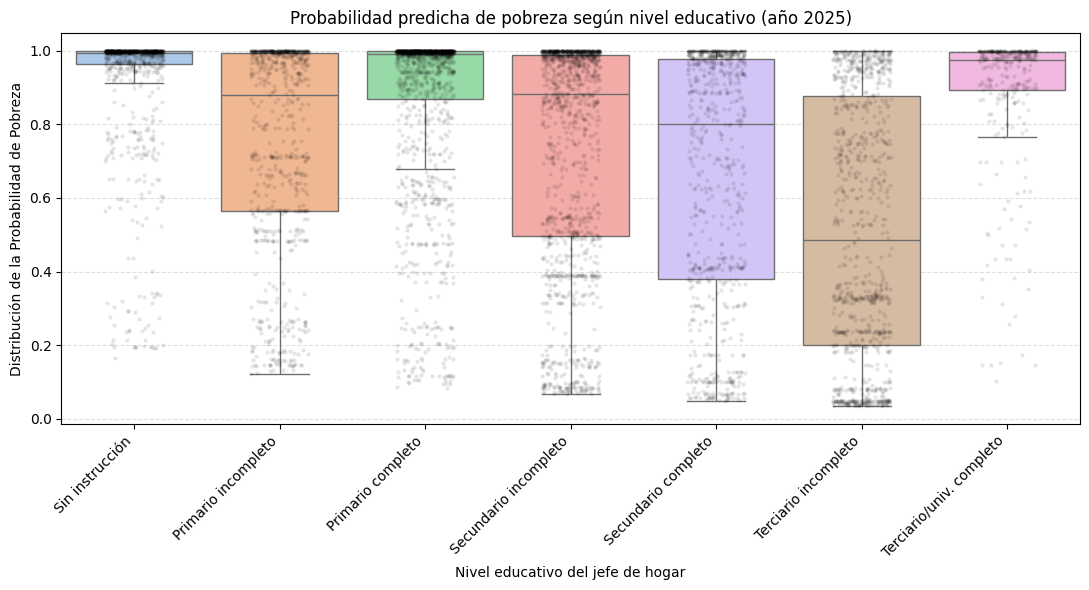

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  # <-- Biblioteca nueva/requerida

# --- Tu código de preparación de datos (sin cambios) ---

# Año y variable a graficar
año = 2025
variable = 'nivel_ed'

# Probabilidad predicha (Asumiendo que 'splits' y 'res' ya existen)
X_train = splits[año]["X_train"]
prob_pred = res.predict(X_train[res.params.index])

# DataFrame para graficar
# (Ya no es necesario .sort_values() para un boxplot)
df_plot = pd.DataFrame({
    variable: X_train[variable], 
    'Prob_Pobre': prob_pred
})

# Etiquetas del nivel educativo
etiquetas_nivel = {
    1: "Sin instrucción",
    2: "Primario incompleto",
    3: "Primario completo",
    4: "Secundario incompleto",
    5: "Secundario completo",
    6: "Terciario incompleto",
    7: "Terciario/univ. completo"
}

# --- NUEVOS PASOS DE PREPARACIÓN (para Seaborn) ---

# 1. Crear una nueva columna con las etiquetas de texto
#    Seaborn usará esto para las categorías del eje X
df_plot['Nivel Educativo'] = df_plot[variable].map(etiquetas_nivel)

# 2. Crear una lista con el orden correcto de las categorías
#    (Si no, Seaborn las ordenaría alfabéticamente)
category_order = list(etiquetas_nivel.values())


# --- CÓDIGO DE GRÁFICO REEMPLAZADO ---

plt.figure(figsize=(11, 6)) # Un poco más ancho para las etiquetas

# 1. Dibujar el Boxplot
sns.boxplot(
    data=df_plot,
    x='Nivel Educativo',      # La nueva columna de texto
    y='Prob_Pobre',
    order=category_order,     # Asegurar el orden correcto
    showfliers=False,         # Oculta outliers (los mostraremos con el stripplot)
    palette='pastel'          # Una paleta de colores suave
)

# 2. Superponer los puntos (scatter/strip plot)
sns.stripplot(
    data=df_plot,
    x='Nivel Educativo',
    y='Prob_Pobre',
    order=category_order,
    alpha=0.1,                # Transparencia (como la tenías)
    s=3,                      # Tamaño de punto más pequeño
    jitter=0.2,               # <-- Esta es la clave: dispersa los puntos
    color='black'             # Color para los puntos
)

# Etiquetas y formato (similar a tu código)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Nivel educativo del jefe de hogar")
plt.ylabel("Distribución de la Probabilidad de Pobreza") # Título Y actualizado
plt.title(f'Probabilidad predicha de pobreza según nivel educativo (año {año})')
plt.grid(True, axis='y', linestyle='--', alpha=0.4) # Grid solo en eje Y
plt.tight_layout()
plt.show()

## **C. Método de Vecinos Cercanos (KNN)**

### 5. Estimación

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

año = 2025
Xtr = splits[año]["X_train"].drop(columns=["intercepto"], errors="ignore").copy()
ytr = splits[año]["y_train"].copy()
Xte = splits[año]["X_test"].drop(columns=["intercepto"], errors="ignore").copy()
yte = splits[año]["y_test"].copy()

# --- 1) Reclasificar columnas object: numéricas "disfrazadas" vs texto real ---
obj_cols = Xtr.select_dtypes(include="object").columns.tolist()

num_like, cat_cols = [], []
for c in obj_cols:
    s = pd.to_numeric(pd.concat([Xtr[c], Xte[c]], axis=0), errors="coerce")
    # si al menos 90% se puede convertir a número, la tratamos como numérica
    if s.notna().mean() >= 0.9:
        # convertir en ambos sets
        Xtr[c] = pd.to_numeric(Xtr[c], errors="coerce")
        Xte[c] = pd.to_numeric(Xte[c], errors="coerce")
        num_like.append(c)
    else:
        cat_cols.append(c)

num_cols = Xtr.select_dtypes(include=[np.number]).columns.tolist()
# asegurar que no quede ninguna numérica en cat
cat_cols = [c for c in cat_cols if c not in num_cols]

# Opcional: descartar posibles IDs de cardinalidad altísima (evita matrices gigantes)
high_card = [c for c in cat_cols if Xtr[c].nunique() > 0.5 * len(Xtr)]
cat_cols = [c for c in cat_cols if c not in high_card]

# --- 2) Preprocesamiento ---
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# --- 3) KNN con K = 1, 5, 10 ---
resultados = []
for k in [1, 5, 10]:
    clf = Pipeline(steps=[("prep", preprocess),
                         ("knn", KNeighborsClassifier(n_neighbors=k))])
    clf.fit(Xtr, ytr)
    yhat = clf.predict(Xte)
    resultados.append({"K": k, "Accuracy_test": accuracy_score(yte, yhat)})

pd.DataFrame(resultados)


C:\Users\loloa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\loloa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\loloa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['estado' 'nivel ed']. At least one non-missing value is needed for imputati

,K,Accuracy_test
0,1,0.845824
1,5,0.875803
2,10,0.871877


### 6. Visualización

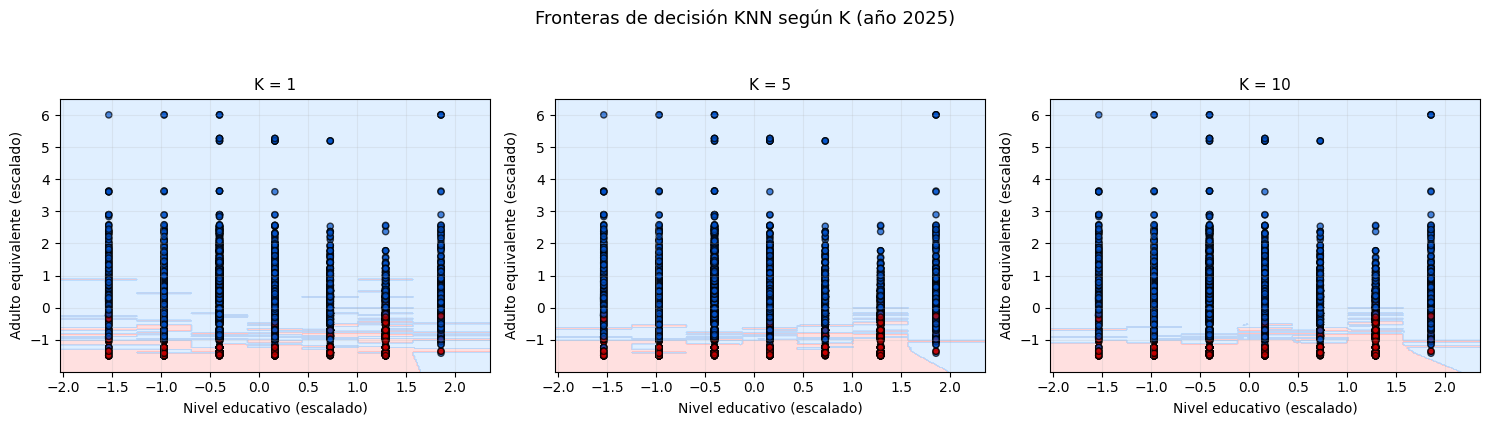

In [12]:
#OPCION A

import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Año y variables a graficar
año = 2025
vars_plot = ["nivel_ed", "ad_equiv_hogar"]

X = splits[año]["X_train"][vars_plot].copy()
y = splits[año]["y_train"].copy()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Grilla para la frontera
x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Paleta de colores
from matplotlib.colors import ListedColormap
cmap_background = ListedColormap(["#ffb3b3", "#b3d9ff"])  # rojo claro / azul claro
cmap_points = ListedColormap(["#cc0000", "#0052cc"])      # rojo / azul

# Gráfico comparativo K = 1, 5, 10
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, [1, 5, 10]):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_scaled, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_background)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap=cmap_points, s=20, edgecolor="k", alpha=0.7)
    ax.set_title(f"K = {k}", fontsize=11)
    ax.set_xlabel("Nivel educativo (escalado)")
    ax.set_ylabel("Adulto equivalente (escalado)")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())

fig.suptitle(f"Fronteras de decisión KNN según K (año {año})", fontsize=13, y=1.05)
plt.tight_layout()
plt.show()


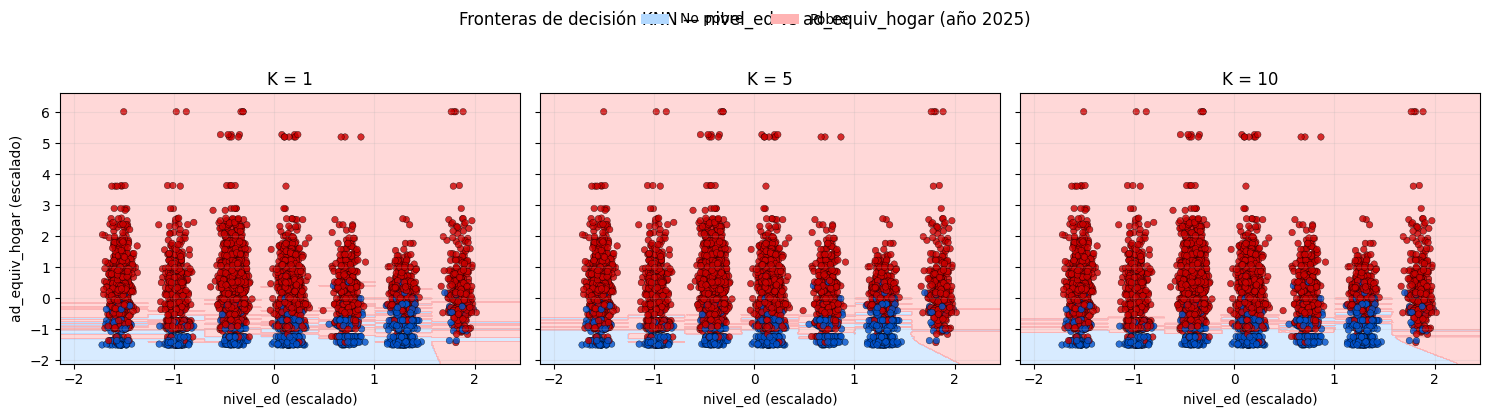

In [13]:
#OPCION B

import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

año = 2025
vars_plot = ["nivel_ed", "ad_equiv_hogar"]  # mismas que venías usando
df = splits[año]["X_train"][vars_plot].dropna().copy()
y  = splits[año]["y_train"].loc[df.index].values

scaler = StandardScaler()
Xz = scaler.fit_transform(df.values)

# jitter suave SOLO para graficar (no para entrenar)
rng = np.random.default_rng(0)
Xz_plot = Xz.copy()
Xz_plot[:,0] += rng.normal(0, 0.06, size=len(Xz_plot))  # jitter en x

# grilla
pad=0.6
xx, yy = np.meshgrid(
    np.linspace(Xz[:,0].min()-pad, Xz[:,0].max()+pad, 400),
    np.linspace(Xz[:,1].min()-pad, Xz[:,1].max()+pad, 400)
)

cmap_bg  = ListedColormap(["#b3d9ff","#ffb3b3"])
cmap_pts = ListedColormap(["#0052cc","#cc0000"])

fig, axes = plt.subplots(1,3,figsize=(15,4),sharex=True,sharey=True)
for ax, k in zip(axes,[1,5,10]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xz, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.5)
    ax.scatter(Xz_plot[:,0], Xz_plot[:,1], c=y, cmap=cmap_pts, s=22, edgecolor="k", lw=0.3, alpha=0.8)
    ax.set_title(f"K = {k}"); ax.grid(alpha=.2)
    ax.set_xlabel(f"{vars_plot[0]} (escalado)")
axes[0].set_ylabel(f"{vars_plot[1]} (escalado)")
fig.legend([Patch(facecolor="#b3d9ff"), Patch(facecolor="#ffb3b3")],
           ["No pobre","Pobre"], loc="upper center", ncol=2, frameon=False)
fig.suptitle(f"Fronteras de decisión KNN — {vars_plot[0]} vs {vars_plot[1]} (año {año})", y=1.03)
plt.tight_layout(); plt.show()

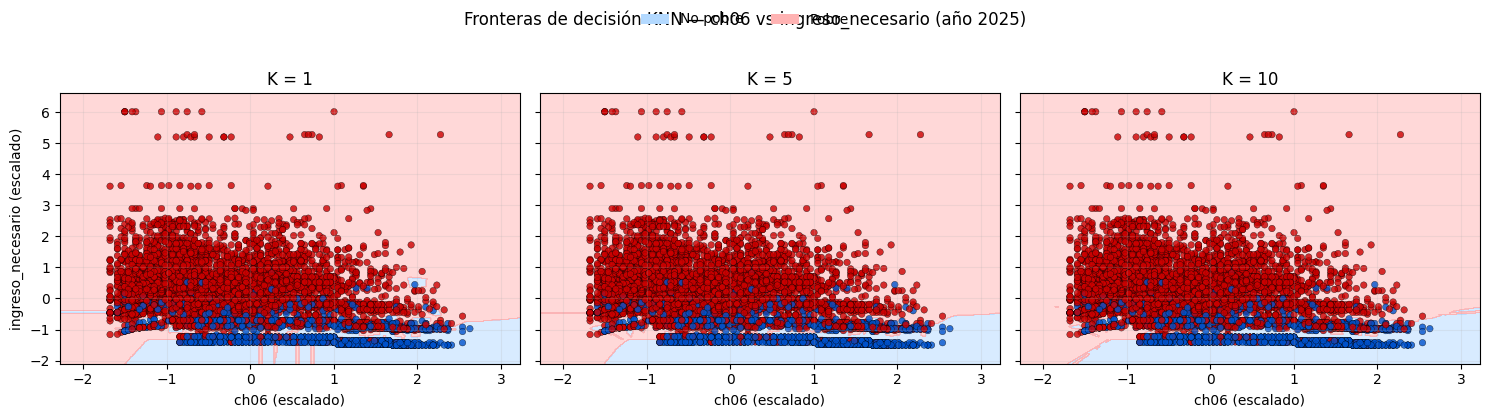

In [14]:
#OPCION C

# reemplazá por 2 variables continuas de tu base
vars_plot = ["ch06", "ingreso_necesario"]  # ejemplo continuo + continuo

df = splits[año]["X_train"][vars_plot].dropna().copy()
y  = splits[año]["y_train"].loc[df.index].values

scaler = StandardScaler()
Xz = scaler.fit_transform(df.values)

pad=0.6
xx, yy = np.meshgrid(
    np.linspace(Xz[:,0].min()-pad, Xz[:,0].max()+pad, 400),
    np.linspace(Xz[:,1].min()-pad, Xz[:,1].max()+pad, 400)
)

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
cmap_bg  = ListedColormap(["#b3d9ff","#ffb3b3"])
cmap_pts = ListedColormap(["#0052cc","#cc0000"])

fig, axes = plt.subplots(1,3,figsize=(15,4),sharex=True,sharey=True)
for ax, k in zip(axes,[1,5,10]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xz, y)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.5)
    ax.scatter(Xz[:,0], Xz[:,1], c=y, cmap=cmap_pts, s=22, edgecolor="k", lw=0.3, alpha=0.8)
    ax.set_title(f"K = {k}"); ax.grid(alpha=.2)
    ax.set_xlabel(f"{vars_plot[0]} (escalado)")
axes[0].set_ylabel(f"{vars_plot[1]} (escalado)")
fig.legend([Patch(facecolor="#b3d9ff"), Patch(facecolor="#ffb3b3")],
           ["No pobre","Pobre"], loc="upper center", ncol=2, frameon=False)
fig.suptitle(f"Fronteras de decisión KNN — {vars_plot[0]} vs {vars_plot[1]} (año {año})", y=1.03)
plt.tight_layout(); plt.show()

### Ejercicio 7

In [15]:
# 1) Datos: respondieron_2025 (si no lo tenés en memoria, filtralo)
# respondieron_2025 = respondieron[respondieron["ano4"] == 2025].copy()

y = respondieron_2025["pobre"].astype(int).copy()
X = respondieron_2025.drop(columns=["pobre", "ingreso", "ipcf", "intercepto"], errors="ignore").copy()

# 2) Columnas numéricas y categóricas
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# (opcional) evitar IDs con cardinalidad altísima
high_card = [c for c in cat_cols if X[c].nunique() > 0.5*len(X)]
cat_cols = [c for c in cat_cols if c not in high_card]

# 3) Preprocesamiento
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# 4) Búsqueda de K por 5-fold CV
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 20, 25]  # podés ajustar el rango
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=444)

cv_stats = []
for k in k_values:
    pipe = Pipeline([("prep", pre), ("knn", KNeighborsClassifier(n_neighbors=k))])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    cv_stats.append({"K": k, "Accuracy_mean": scores.mean(), "Accuracy_std": scores.std()})

cv_df = pd.DataFrame(cv_stats).sort_values("K").reset_index(drop=True)
display(cv_df)

# 5) Gráfico Accuracy vs K
plt.figure(figsize=(7,4))
plt.plot(cv_df["K"], cv_df["Accuracy_mean"], marker="o")
plt.fill_between(cv_df["K"],
                 cv_df["Accuracy_mean"] - cv_df["Accuracy_std"],
                 cv_df["Accuracy_mean"] + cv_df["Accuracy_std"], alpha=0.2)
plt.xlabel("K")
plt.ylabel("Accuracy (5-fold CV)")
plt.title("Selección de K por Cross-Validation (respondieron 2025)")
plt.grid(True, alpha=0.3)
plt.show()

# 6) K óptimo (si hay empate, elijo el menor K)
k_opt = cv_df.loc[cv_df["Accuracy_mean"].idxmax(), "K"]
print("K óptimo por 5-fold CV:", int(k_opt))

# 7) Entrenar el modelo final KNN con K-CV en toda respondieron_2025
knn_cv = Pipeline([("prep", pre), ("knn", KNeighborsClassifier(n_neighbors=int(k_opt)))])
knn_cv.fit(X, y)  # <- este es tu modelo "KNN con K-CV"

NameError: name 'StratifiedKFold' is not defined

## **D. Desempeño de modelos, elección y predicción afuera de la muestra**

### Ejercicio 8

### Ejercicio 9

### Ejercicio 10